In [1]:
from hci import lib
import ctypes
import numpy as np
import math
import pyscf
from pyscf import gto, scf

libhci = lib.libhci
rng = np.random.default_rng()

# Ranking and indexing

In [2]:
norb = 8
nocc = 4
combs = np.empty(min(nocc, norb-nocc)+1, dtype=np.uint64)
inverted = libhci.get_consecutive_combs(combs.ctypes.data_as(ctypes.c_void_p), 
                 ctypes.c_size_t(norb),
                 ctypes.c_size_t(nocc))
print(inverted, combs)

0 [ 1  8 28 56 70]


In [3]:
norb = 8
nocc = 4
rank_table = np.empty((nocc, norb-nocc+1), dtype=np.uint64, order='C')
libhci.get_rank_table(rank_table.ctypes.data_as(ctypes.c_void_p),
                                       ctypes.c_size_t(norb),
                                       ctypes.c_size_t(nocc))
print(rank_table)

[[ 0  1  2  3  4]
 [ 0  1  3  6 10]
 [ 0  1  4 10 20]
 [ 0  1  5 15 35]]


In [4]:
rank = 0
index = libhci.find_row_index(ctypes.c_uint64(rank),
                              rank_table[2][:].ctypes.data_as(ctypes.c_void_p),
                              ctypes.c_size_t(norb),
                              ctypes.c_size_t(nocc))
print(index)

0


In [5]:
import itertools
norb = 8
nocc = 4
# occ_list = np.array([1,3,4,5], dtype=np.int32)
for comb in itertools.combinations(np.arange(norb, dtype=np.uintp), nocc):
    occ_list = np.array(comb)
    rank = libhci.rank(occ_list.ctypes.data_as(ctypes.c_void_p),
                       rank_table.ctypes.data_as(ctypes.c_void_p),
                       ctypes.c_size_t(norb),
                       ctypes.c_size_t(nocc))
    print(occ_list, rank)

[0 1 2 3] 0
[0 1 2 4] 1
[0 1 2 5] 5
[0 1 2 6] 15
[0 1 2 7] 35
[0 1 3 4] 2
[0 1 3 5] 6
[0 1 3 6] 16
[0 1 3 7] 36
[0 1 4 5] 9
[0 1 4 6] 19
[0 1 4 7] 39
[0 1 5 6] 25
[0 1 5 7] 45
[0 1 6 7] 55
[0 2 3 4] 3
[0 2 3 5] 7
[0 2 3 6] 17
[0 2 3 7] 37
[0 2 4 5] 10
[0 2 4 6] 20
[0 2 4 7] 40
[0 2 5 6] 26
[0 2 5 7] 46
[0 2 6 7] 56
[0 3 4 5] 12
[0 3 4 6] 22
[0 3 4 7] 42
[0 3 5 6] 28
[0 3 5 7] 48
[0 3 6 7] 58
[0 4 5 6] 31
[0 4 5 7] 51
[0 4 6 7] 61
[0 5 6 7] 65
[1 2 3 4] 4
[1 2 3 5] 8
[1 2 3 6] 18
[1 2 3 7] 38
[1 2 4 5] 11
[1 2 4 6] 21
[1 2 4 7] 41
[1 2 5 6] 27
[1 2 5 7] 47
[1 2 6 7] 57
[1 3 4 5] 13
[1 3 4 6] 23
[1 3 4 7] 43
[1 3 5 6] 29
[1 3 5 7] 49
[1 3 6 7] 59
[1 4 5 6] 32
[1 4 5 7] 52
[1 4 6 7] 62
[1 5 6 7] 66
[2 3 4 5] 14
[2 3 4 6] 24
[2 3 4 7] 44
[2 3 5 6] 30
[2 3 5 7] 50
[2 3 6 7] 60
[2 4 5 6] 33
[2 4 5 7] 53
[2 4 6 7] 63
[2 5 6 7] 67
[3 4 5 6] 34
[3 4 5 7] 54
[3 4 6 7] 64
[3 5 6 7] 68
[4 5 6 7] 69


In [6]:
norb = 8
nocc = 4

rank_table = np.empty((nocc, norb-nocc+1), dtype=np.uint64)
libhci.get_rank_table(rank_table.ctypes.data_as(ctypes.c_void_p),
                                       ctypes.c_size_t(norb),
                                       ctypes.c_size_t(nocc))
print(rank_table)

rank = 57
occ_list = np.zeros(nocc, dtype=np.uintp)
libhci.unrank(ctypes.c_uint64(rank),
              occ_list.ctypes.data_as(ctypes.c_void_p),
              rank_table.ctypes.data_as(ctypes.c_void_p),
              ctypes.c_size_t(norb),
              ctypes.c_size_t(nocc))
print(occ_list)

[[ 0  1  2  3  4]
 [ 0  1  3  6 10]
 [ 0  1  4 10 20]
 [ 0  1  5 15 35]]
[1 2 6 7]


# Double excitation storage

In [7]:
from hci import lib
import numpy as np
libhci = lib.libhci
rng = np.random.default_rng()

norb = 10
na = 5
nb = 3
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, (na, nb))

print(config_table_a)
print(config_table_b)
print(exc_table_4o)
print(exc_table_2o)

nij = norb*(norb+1)//2
mock_eri_s8 = rng.random(nij*(nij+1)//2)
mock_eri_s4 = rng.random(nij**2)

doubles_aa = lib.get_stored_double_exc(mock_eri_s8, exc_table_4o, norb)
max_mag_aa = lib.get_max_magnitudes(doubles_aa, norb)
doubles_aa = doubles_aa[np.argsort(max_mag_aa)[::-1]]

doubles_bb = lib.get_stored_double_exc(mock_eri_s8, exc_table_4o, norb)
max_mag_bb = lib.get_max_magnitudes(doubles_bb, norb)
doubles_bb = doubles_bb[np.argsort(max_mag_bb)[::-1]]

mixed_ab = lib.get_stored_mixed_exc(mock_eri_s4, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
mixed_ab = mixed_ab[np.argsort(max_mag_ab)[::-1]]

print(doubles_aa)
print(doubles_bb)
print(mixed_ab)

[[  0   1   2   3   4   5]
 [  0   1   3   6  10  15]
 [  0   1   4  10  20  35]
 [  0   1   5  15  35  70]
 [  0   1   6  21  56 126]]
[[ 0  1  2  3  4  5  6  7]
 [ 0  1  3  6 10 15 21 28]
 [ 0  1  4 10 20 35 56 84]]
[[  0   1   2   3   4   5   6]
 [  0   1   3   6  10  15  21]
 [  0   1   4  10  20  35  56]
 [  0   1   5  15  35  70 126]]
[[ 0  1  2  3  4  5  6  7  8]
 [ 0  1  3  6 10 15 21 28 36]]
[( 98,  8.55829872e-01, -9.74832010e-01)
 (167, -4.70402555e-01,  9.70012479e-01)
 ( 66,  7.41450785e-01,  2.25321793e-01)
 (151, -9.54316986e-01,  7.69864028e-01)
 ( 37, -9.43568507e-01,  6.26954639e-01)
 ( 59, -9.42964983e-01,  7.23474241e-01)
 ( 77, -7.78734407e-01, -1.62259835e-01)
 (133, -8.95609545e-01, -2.86380374e-02)
 (121,  1.56304786e-01, -9.23499099e-01)
 (198, -9.07248356e-01,  5.31167605e-01)
 (176, -2.74700644e-01,  8.98689512e-01)
 (132, -7.10484764e-01, -1.72498949e-01)
 (166,  2.63248870e-01, -8.77140666e-01)
 (150,  8.66682235e-01, -4.09019803e-01)
 (193, -8.56965618e-01

In [8]:
magnitudes = np.empty(math.comb(norb, 4), dtype=np.double)
libhci.get_max_magnitudes(doubles_aa.ctypes.data_as(ctypes.c_void_p),
                          magnitudes.ctypes.data_as(ctypes.c_void_p),
                          ctypes.c_size_t(math.comb(norb,4)))
print(magnitudes)

[0.97483201 0.97001248 0.96677258 0.95431699 0.94356851 0.94296498
 0.94099424 0.92424758 0.9234991  0.90724836 0.89868951 0.88298371
 0.87714067 0.86668223 0.85696562 0.83690209 0.83670105 0.83258929
 0.82602809 0.81250029 0.8089202  0.80291061 0.80234999 0.78848554
 0.78535344 0.78385331 0.78001923 0.77999464 0.77638072 0.75453112
 0.75277491 0.75219859 0.74187778 0.7333558  0.71870929 0.71800659
 0.71403627 0.71342557 0.71081121 0.71026606 0.70042549 0.69909053
 0.69248749 0.69208046 0.67813124 0.67627131 0.67282558 0.67267833
 0.67190167 0.66784229 0.66239239 0.65905889 0.65854581 0.65782755
 0.64721369 0.64463631 0.64262427 0.6390356  0.63762448 0.63560895
 0.63220615 0.63201136 0.63183032 0.627186   0.61977847 0.61829717
 0.61645946 0.61619568 0.61449128 0.61283197 0.60800566 0.60727451
 0.60027811 0.59931519 0.5980404  0.59749278 0.59620487 0.59614643
 0.58066151 0.58041111 0.57998926 0.5721305  0.57024393 0.56929826
 0.56374723 0.5622496  0.56206219 0.56138435 0.55787681 0.5563

In [9]:
print(magnitudes-(doubles_aa['ijkl']+doubles_aa['iljk']))

[1.09383415e+00 4.70402555e-01 0.00000000e+00 1.13876994e+00
 1.26018237e+00 1.16245573e+00 1.88198848e+00 1.84849516e+00
 1.69069341e+00 1.28332911e+00 2.74700644e-01 1.76596743e+00
 1.49103246e+00 4.09019803e-01 1.55050822e+00 7.51040390e-01
 1.67340210e+00 1.18832267e+00 2.85144749e-02 4.47791172e-01
 1.27316003e+00 1.60582122e+00 1.52179811e+00 0.00000000e+00
 1.44113885e-03 0.00000000e+00 1.25276554e+00 2.16379331e-01
 1.55276144e+00 5.04853414e-01 1.45848582e+00 1.06428416e-01
 1.15053978e-01 1.22802890e+00 1.43741859e+00 1.14873654e+00
 1.42807254e+00 1.26010292e+00 3.84121574e-01 1.42053212e+00
 1.40085098e+00 1.24472974e+00 1.23388575e+00 1.50640443e-01
 3.30478708e-01 4.42912520e-01 1.18846765e+00 0.00000000e+00
 1.25651511e+00 9.51365159e-01 5.07876182e-01 0.00000000e+00
 1.31709163e+00 1.31565509e+00 9.64288507e-01 8.85916160e-01
 0.00000000e+00 0.00000000e+00 1.27524896e+00 1.19604415e+00
 4.46629548e-01 2.74540136e-02 0.00000000e+00 1.24976764e+00
 1.13825218e+00 5.064868

# Subspace enlargement

## H2 - mixed only

In [10]:
import hci.hci_uhf
from pyscf import gto, scf
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np

In [11]:
mol = gto.M(
    atom = '''
H    -0.340000    0.000000    0.000000
H    0.340000    0.000000    0.000000''',
    basis = '3-21g',
    charge = 0,
    spin = 0  # = 2S = spin_up - spin_down
)

In [12]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -1.12046039838593  <S^2> = 1.110223e-15  2S+1 = 1


np.float64(-1.1204603983859307)

In [13]:
mf.scf_summary

{'nuc': np.float64(0.7782017807647059),
 'e1': np.float64(-2.573679301158442),
 'e2': np.float64(0.6750171220078054)}

In [14]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)
print(mo)

4 (1, 1)
[[[ 0.29920008  0.10240537  0.75808043 -1.12464738]
  [ 0.29744806  1.77543079 -0.65876995  1.31493919]
  [ 0.29920008 -0.10240537  0.75808043  1.12464738]
  [ 0.29744806 -1.77543079 -0.65876995 -1.31493919]]

 [[ 0.2992001   0.10240537  0.75808042  1.12464738]
  [ 0.29744805  1.77543078 -0.65876996 -1.3149392 ]
  [ 0.2992001  -0.10240537  0.75808042 -1.12464738]
  [ 0.29744805 -1.77543078 -0.65876996  1.3149392 ]]]


In [15]:
hci.hci_uhf.kernel(hcore, eri_ao, mo, norb, nelec, 0.0)

[[3 3]
 [2 2]
 [1 1]
 [1 3]
 [3 1]
 [3 2]
 [1 2]
 [2 3]
 [2 1]]
[[1 0]
 [2 0]
 [3 0]
 [0 1]
 [0 2]
 [0 3]]



## Water - all types

In [16]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np
import ctypes
from functools import reduce
import math

In [17]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [18]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221476)

In [19]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.41508892506982),
 'e2': np.float64(32.57011896354531)}

In [20]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [21]:
hci.hci_uhf.kernel(hcore, eri_ao, mo, norb, nelec, 0.02)

[[18  0]
 [ 0 28]
 [ 8 16]
 [ 4  7]
 [ 8  7]
 [ 4 16]
 [ 1 16]
 [ 3  6]
 [ 8  5]
 [ 1  7]
 [ 6 15]
 [ 1  5]
 [ 2  3]
 [ 4  5]
 [ 9 17]
 [ 6  6]
 [ 3 17]
 [ 3 15]
 [ 9  6]
 [ 5  8]
 [ 7  2]]
[]



In [22]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(7, (5, 4))

In [23]:
a_rank = 18
b_rank = 0
occ_a = np.empty(5, dtype=np.uint64)
occ_b = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(a_rank), 
                      occ_a.ctypes.data_as(ctypes.c_void_p),
                      config_table_a.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(5))
hci.lib.libhci.unrank(ctypes.c_uint64(b_rank), 
                      occ_b.ctypes.data_as(ctypes.c_void_p),
                      config_table_b.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(occ_a, occ_b)

[0 3 4 5 6] [0 1 2 3]


In [24]:
exc_rank_aa = 27
exc_aa = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(exc_rank_aa), 
                      exc_aa.ctypes.data_as(ctypes.c_void_p),
                      exc_table_4o.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(exc_aa)

[1 2 5 6]


In [25]:
exc_rank_bb = 0
exc_bb = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(exc_rank_bb), 
                      exc_bb.ctypes.data_as(ctypes.c_void_p),
                      exc_table_4o.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(exc_bb)

[0 1 2 3]


In [26]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa_s1 = ao2mo.restore('s1', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb_s1 = ao2mo.restore('s1', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb_s1 = ao2mo.restore('s1', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [27]:
def index_2d(i, j):
    if i>j:
        return math.comb(i+1, 2)+j
    else:
        return math.comb(j+1, 2)+i

def index_4d(i, j, k, l):
    return index_2d(index_2d(i, j), index_2d(k, l))

In [28]:
eri_mo_aaaa_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
i = 1
j = 2
k = 5
l = 6
print(eri_mo_aaaa_s1[i,j,k,l]-eri_mo_aaaa_s1[i,l,k,j])
print(eri_mo_aaaa_s8[index_4d(i,j,k,l)]-eri_mo_aaaa_s8[index_4d(i,l,k,j)])

0.06755658843298327
0.06755658843298329


## Full testing script

In [29]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np
import ctypes
from functools import reduce
import math

In [30]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [31]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322147  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221473)

In [32]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.41508892506978),
 'e2': np.float64(32.5701189635453)}

In [33]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [34]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [35]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(norb, nelec)

In [36]:
doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)

In [37]:
print(doubles_aa)

[( 0,  3.21667135e-17,  4.35582971e-19)
 ( 1, -4.92703941e-18, -1.33052712e-18)
 ( 2, -5.75629915e-18,  9.80711344e-19)
 ( 3, -9.95116558e-18,  1.01609027e-17)
 ( 4,  6.03774782e-18, -4.23593853e-18)
 ( 5, -1.79635793e-16,  4.52745744e-17)
 ( 6, -1.73797436e-17,  1.03399220e-18)
 ( 7, -2.67005090e-17,  2.70324602e-17)
 ( 8, -2.67962135e-17,  3.02042982e-17)
 ( 9,  2.03187800e-02, -1.17654898e-03)
 (10,  3.08217427e-17,  1.73074304e-17)
 (11,  1.98779899e-16, -1.72979100e-16)
 (12, -2.12490151e-20,  2.43947670e-18)
 (13,  6.59009449e-18, -1.76896411e-18)
 (14,  6.32678621e-17,  5.69660491e-20)
 (15, -3.13597976e-02,  8.63432154e-03)
 (16, -4.92308928e-17,  1.51113569e-17)
 (17, -9.33795885e-19, -2.60223828e-18)
 (18, -1.19270909e-17,  2.02153688e-17)
 (19, -1.24313283e-16,  8.34556678e-18)
 (20,  4.15750321e-03,  3.11445775e-03)
 (21,  3.57162742e-02, -3.32249047e-02)
 (22,  7.27625376e-18,  3.88525929e-18)
 (23,  6.25088332e-17, -5.65041863e-17)
 (24, -9.40888332e-18,  8.03389217e-18)


In [38]:
doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
max_mag_aa = hci.lib.get_max_magnitudes(doubles_aa, norb)
sorted_indices = np.argsort(max_mag_aa)[::-1]
doubles_aa = doubles_aa[sorted_indices]
max_mag_aa = max_mag_aa[sorted_indices]

doubles_bb = hci.lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
max_mag_bb = hci.lib.get_max_magnitudes(doubles_bb, norb)
sorted_indices = np.argsort(max_mag_bb)[::-1]
doubles_bb = doubles_bb[sorted_indices]
max_mag_bb = max_mag_bb[sorted_indices]

mixed_ab = hci.lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
sorted_indices = np.argsort(max_mag_ab)[::-1]
mixed_ab = mixed_ab[sorted_indices]
max_mag_ab = max_mag_ab[sorted_indices]

In [39]:
ranks = np.array([[0, 0]], dtype=np.uint64)
coeffs = np.array([1.0], dtype=np.double)

### Double excitations

In [40]:
add_thresh = 0.01
add_list, nadd = hci.lib.enlarge_space_doubles(ranks, coeffs, norb, nelec_a, nelec_b, add_thresh, 
                                               config_table_a, config_table_b, exc_table_4o, exc_table_2o, 
                                               doubles_aa, doubles_bb, mixed_ab,
                                               max_mag_aa, max_mag_bb, max_mag_ab)

In [41]:
a_occ = np.zeros(nelec_a, dtype=np.uint64)
b_occ = np.zeros(nelec_b, dtype=np.uint64)
hci.lib.unrank(0, a_occ, config_table_a, norb, nelec_a)
hci.lib.unrank(0, b_occ, config_table_b, norb, nelec_b)
ci0_astr = set(a_occ)
ci0_bstr = set(b_occ)
eri_mo_aaaa_s1 = ao2mo.restore('s1', eri_mo_aaaa, norb)
eri_mo_bbbb_s1 = ao2mo.restore('s1', eri_mo_bbbb, norb)
eri_mo_aabb_s1 = ao2mo.restore('s1', eri_mo_aabb, norb)
for entry in add_list[:nadd]:
    arank = entry[0]
    brank = entry[1]
    print(arank, brank)
    hci.lib.unrank(arank, a_occ, config_table_a, norb, nelec_a)
    hci.lib.unrank(brank, b_occ, config_table_b, norb, nelec_b)
    print(a_occ, b_occ)
    excdet_astr = set(a_occ)
    excdet_bstr = set(b_occ)
    holeorbs_a = ci0_astr - excdet_astr
    holeorbs_b = ci0_bstr - excdet_bstr
    partorbs_a = excdet_astr - ci0_astr
    partorbs_b = excdet_bstr - ci0_bstr
    print(holeorbs_a, holeorbs_b, partorbs_a, partorbs_b)
    assert(len(holeorbs_a) + len(holeorbs_b) == 2)
    assert(len(partorbs_a) + len(partorbs_b) == 2)
    if len(holeorbs_a)==2:
        print(f'aa excitation from orbitals {holeorbs_a} to {partorbs_a}')
        sorted_holeorbs_a = sorted(holeorbs_a)
        sorted_partorbs_a = sorted(partorbs_a)
        a = sorted_holeorbs_a[0]
        b = sorted_holeorbs_a[1]
        c = sorted_partorbs_a[0]
        d = sorted_partorbs_a[1]
        val = abs(eri_mo_aaaa_s1[a,c,b,d]-eri_mo_aaaa_s1[a,d,b,c])
        assert(val > add_thresh)
    elif len(holeorbs_a)==1:
        print(f'ab excitation from a orbital {holeorbs_a} to {partorbs_a} and b orbital {holeorbs_b} to {partorbs_b}')
        a = holeorbs_a.pop()
        b = holeorbs_b.pop()
        c = partorbs_a.pop()
        d = partorbs_b.pop()
        val = abs(eri_mo_aabb_s1[a,c,b,d])
        assert(val > add_thresh)
    else:
        print(f'bb excitation from orbitals {holeorbs_b} to {partorbs_b}')
        sorted_holeorbs_b = sorted(holeorbs_b)
        sorted_partorbs_b = sorted(partorbs_b)
        a = sorted_holeorbs_b[0]
        b = sorted_holeorbs_b[1]
        c = sorted_partorbs_b[0]
        d = sorted_partorbs_b[1]
        val = abs(eri_mo_bbbb_s1[a,c,b,d]-eri_mo_bbbb_s1[a,d,b,c])
        assert(val > add_thresh)
    print()

18 0
[0 3 4 5 6] [0 1 2 3]
{np.uint64(1), np.uint64(2)} set() {np.uint64(5), np.uint64(6)} set()
aa excitation from orbitals {np.uint64(1), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

19 0
[1 3 4 5 6] [0 1 2 3]
{np.uint64(0), np.uint64(2)} set() {np.uint64(5), np.uint64(6)} set()
aa excitation from orbitals {np.uint64(0), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

0 28
[0 1 2 3 4] [0 3 5 6]
set() {np.uint64(1), np.uint64(2)} set() {np.uint64(5), np.uint64(6)}
bb excitation from orbitals {np.uint64(1), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

0 29
[0 1 2 3 4] [1 3 5 6]
set() {np.uint64(0), np.uint64(2)} set() {np.uint64(5), np.uint64(6)}
bb excitation from orbitals {np.uint64(0), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

8 16
[0 1 3 4 6] [0 1 3 6]
{np.uint64(2)} {np.uint64(2)} {np.uint64(6)} {np.uint64(6)}
ab excitation from a orbital {np.uint64(2)} to {np.uint64(6)} and b orbital {np.uint64(2)} to {np.uint64(6)}

4 7
[0 2 3 4 5] [0 2 3 5]
{np.uint64(1)} {np.uint64(1)}

### Single excitations

In [42]:
add_thresh = 0.0
add_list, nadd = hci.lib.enlarge_space_singles(ranks, coeffs, norb, nelec_a, nelec_b, add_thresh,
                                               config_table_a, config_table_a_complement,
                                               config_table_b, config_table_b_complement,
                                               h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

In [43]:
a_occ = np.zeros(nelec_a, dtype=np.uint64)
b_occ = np.zeros(nelec_b, dtype=np.uint64)
hci.lib.unrank(0, a_occ, config_table_a, norb, nelec_a)
hci.lib.unrank(0, b_occ, config_table_b, norb, nelec_b)
ci0_astr = set(a_occ)
ci0_bstr = set(b_occ)
for entry in add_list[:nadd]:
    arank = entry[0]
    brank = entry[1]
    print(arank, brank)
    hci.lib.unrank(arank, a_occ, config_table_a, norb, nelec_a)
    hci.lib.unrank(brank, b_occ, config_table_b, norb, nelec_b)
    print(a_occ, b_occ)
    excdet_astr = set(a_occ)
    excdet_bstr = set(b_occ)
    holeorbs_a = ci0_astr - excdet_astr
    holeorbs_b = ci0_bstr - excdet_bstr
    partorbs_a = excdet_astr - ci0_astr
    partorbs_b = excdet_bstr - ci0_bstr
    print(holeorbs_a, holeorbs_b, partorbs_a, partorbs_b)
    assert(len(holeorbs_a) + len(holeorbs_b) == 1)
    assert(len(partorbs_a) + len(partorbs_b) == 1)
    if len(holeorbs_a)==1:
        print(f'a excitation from orbitals {holeorbs_a} to {partorbs_a}')
    else:
        print(f'b excitation from orbitals {holeorbs_b} to {partorbs_b}')
    print()

5 0
[1 2 3 4 5] [0 1 2 3]
{np.uint64(0)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(0)} to {np.uint64(5)}

10 0
[1 2 3 4 6] [0 1 2 3]
{np.uint64(0)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(0)} to {np.uint64(6)}

4 0
[0 2 3 4 5] [0 1 2 3]
{np.uint64(1)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(1)} to {np.uint64(5)}

9 0
[0 2 3 4 6] [0 1 2 3]
{np.uint64(1)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(1)} to {np.uint64(6)}

3 0
[0 1 3 4 5] [0 1 2 3]
{np.uint64(2)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(2)} to {np.uint64(5)}

8 0
[0 1 3 4 6] [0 1 2 3]
{np.uint64(2)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(2)} to {np.uint64(6)}

2 0
[0 1 2 4 5] [0 1 2 3]
{np.uint64(3)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(3)} to {np.uint64(5)}

7 0
[0 1 2 4 6] [0 1 2 3]
{np.uint64(3)} set() {np.uint64(6)} set()
a excitation from orbitals {

# Complement finding

In [44]:
norb = 13
nelec = 3
ncomp = norb-nelec
config_table, config_table_comp, _, _, _, _ = hci.lib.get_ranking_tables(norb, (nelec, ncomp))
print(config_table)
print(config_table_comp)

[[  0   1   2   3   4   5   6   7   8   9  10]
 [  0   1   3   6  10  15  21  28  36  45  55]
 [  0   1   4  10  20  35  56  84 120 165 220]]
[[ 0  1  2  3]
 [ 0  1  3  6]
 [ 0  1  4 10]
 [ 0  1  5 15]
 [ 0  1  6 21]
 [ 0  1  7 28]
 [ 0  1  8 36]
 [ 0  1  9 45]
 [ 0  1 10 55]
 [ 0  1 11 66]]


In [45]:
config = np.zeros(nelec, dtype=np.uint64)
complement = np.zeros(norb-nelec, dtype=np.uint64)
for i in range(math.comb(norb, nelec)):
    hci.lib.unrank(i, config, config_table, norb, nelec)
    hci.lib.unrank(math.comb(norb, nelec)-i-1, complement, config_table_comp, norb, norb-nelec)
    assert((np.union1d(config, complement) == np.arange(norb)).all())
    assert(np.intersect1d(config, complement).size == 0)

# Verification of matrix element calculations

In [11]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt

In [12]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [13]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322147  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221475)

In [14]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.4150889250698),
 'e2': np.float64(32.5701189635453)}

In [15]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [16]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [17]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(norb, nelec)

In [18]:
ordered_doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
ordered_doubles_bb = hci.lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
ordered_mixed_ab = hci.lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)

In [19]:
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_aa, h1e_bb), (eri_mo_aaaa, eri_mo_aabb, eri_mo_bbbb), norb, nelec, np=ndets)

In [20]:
print(full_hamiltonian.shape)

(735, 735)


In [21]:
na = cistring.num_strings(norb, nelec_a)
nb = cistring.num_strings(norb, nelec_b)
addr = np.arange(na*nb)
addra = addr // nb
addrb = addr % nb
stra = cistring.addrs2str(norb, nelec_a, addra)
strb = cistring.addrs2str(norb, nelec_b, addrb)
occlsta = cistring._strs2occslst(stra, norb).astype(np.uintp)
occlstb = cistring._strs2occslst(strb, norb).astype(np.uintp)
ranka = np.zeros(na*nb, dtype=np.uint64)
rankb = np.zeros(na*nb, dtype=np.uint64)

In [22]:
for i, occs in enumerate(occlsta):
    ranka[i] = hci.lib.rank(occs, config_table_a, norb, nelec_a)

for i, occs in enumerate(occlstb):
    rankb[i] = hci.lib.rank(occs, config_table_b, norb, nelec_b)

In [23]:
check_hamiltonian_1 = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
check_hamiltonian_2 = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
for i in range(full_hamiltonian.shape[0]):
    ranka_1 = ranka[i]
    rankb_1 = rankb[i]
    for j in range(full_hamiltonian.shape[1]):
        ranka_2 = ranka[j]
        rankb_2 = rankb[j]
        check_hamiltonian_1[i,j] = hci.lib.get_matrix_element_by_rank_test_storage(ranka_1, rankb_1, ranka_2, rankb_2,
                                                                                   config_table_a, config_table_b, exc_table_4o, exc_table_2o,
                                                                                   norb, nelec_a, nelec_b,
                                                                                   ordered_doubles_aa, ordered_doubles_bb, ordered_mixed_ab,
                                                                                   h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)
        check_hamiltonian_2[i,j] = hci.lib.get_matrix_element_by_rank(ranka_1, rankb_1, ranka_2, rankb_2,
                                                                      config_table_a, config_table_b,
                                                                      norb, nelec_a, nelec_b,
                                                                      h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

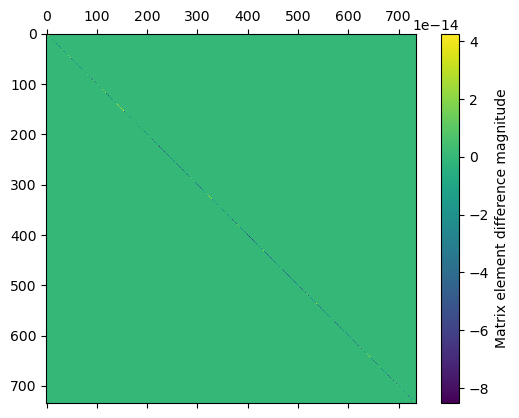

In [24]:
fig, ax = plt.subplots()
im = ax.matshow(full_hamiltonian-check_hamiltonian_1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

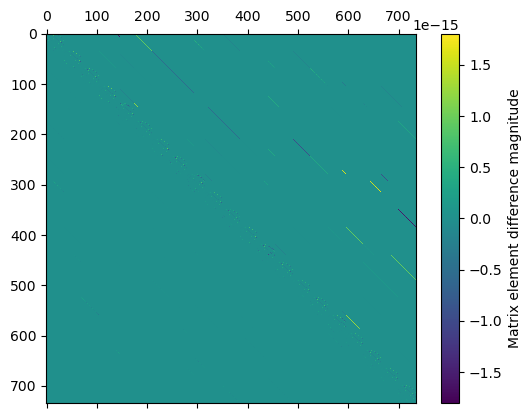

In [25]:
fig, ax = plt.subplots()
diffs = full_hamiltonian-check_hamiltonian_1
np.fill_diagonal(diffs, 0.0)
im = ax.matshow(diffs)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

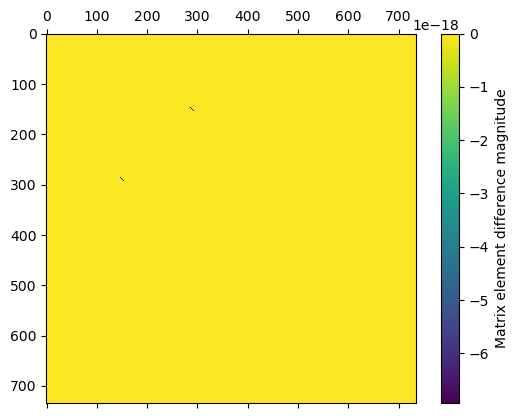

In [28]:
fig, ax = plt.subplots()
im = ax.matshow(check_hamiltonian_1-check_hamiltonian_2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

# Final enlargement code

In [2]:
import hci
from hci import lib, HCI
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
myhci = hci.HCI()

In [3]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

mf = scf.UHF(mol)
mf.kernel()

nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri

mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, nelec)

doubles_aa = lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
max_mag_aa = lib.get_max_magnitudes(doubles_aa, norb)
sorted_indices = np.argsort(max_mag_aa)[::-1]
doubles_aa = doubles_aa[sorted_indices]
max_mag_aa = max_mag_aa[sorted_indices]

doubles_bb = lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
max_mag_bb = lib.get_max_magnitudes(doubles_bb, norb)
sorted_indices = np.argsort(max_mag_bb)[::-1]
doubles_bb = doubles_bb[sorted_indices]
max_mag_bb = max_mag_bb[sorted_indices]

mixed_ab = lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
sorted_indices = np.argsort(max_mag_ab)[::-1]
mixed_ab = mixed_ab[sorted_indices]
max_mag_ab = max_mag_ab[sorted_indices]

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


In [7]:
thresh = 0.01

ranks = np.array([[1, 3], [2,4]], dtype=np.uint64)
coeffs = [np.array([0.707, 0.707], dtype=np.double)]

ranks_new, coeffs_new = myhci.enlarge_space(ranks, coeffs, norb, nelec_a, nelec_b, thresh,
                                            config_table_a, config_table_a_complement, 
                                            config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o,
                                            doubles_aa, doubles_bb, mixed_ab, max_mag_aa, max_mag_bb, max_mag_ab,
                                            h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

print(ranks)
print(coeffs)
print(ranks_new)
print(coeffs_new)

[[1 3]
 [2 4]]
[array([0.707, 0.707])]
[[ 0  0]
 [ 0  1]
 [ 0  3]
 [ 0  8]
 [ 0 10]
 [ 0 22]
 [ 1  0]
 [ 1  1]
 [ 1  3]
 [ 1  4]
 [ 1 10]
 [ 1 11]
 [ 1 22]
 [ 1 23]
 [ 1 34]
 [ 2  0]
 [ 2  1]
 [ 2  3]
 [ 2  4]
 [ 2 10]
 [ 2 11]
 [ 2 14]
 [ 2 19]
 [ 2 22]
 [ 2 23]
 [ 2 34]
 [ 3 12]
 [ 3 18]
 [ 3 20]
 [ 4  0]
 [ 4  1]
 [ 4  3]
 [ 4  4]
 [ 4  8]
 [ 4 10]
 [ 4 14]
 [ 4 22]
 [ 5  0]
 [ 5  1]
 [ 5  4]
 [ 5  8]
 [ 6  2]
 [ 6 12]
 [ 6 20]
 [ 6 24]
 [ 7  2]
 [ 7 13]
 [ 7 21]
 [ 7 24]
 [ 8  3]
 [11  2]
 [11 13]
 [11 17]
 [11 21]
 [12  1]
 [12  3]
 [12  4]
 [12 10]
 [12 22]
 [13  2]
 [13 12]
 [13 20]
 [13 24]
 [14  2]
 [14 20]
 [14 24]
 [15  3]
 [15  4]
 [15 11]
 [15 14]
 [15 23]
 [16  2]
 [16 13]
 [16 21]
 [16 24]
 [17  2]
 [17 21]
 [17 24]
 [19  3]]
[array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.707,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.707, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0. 

# Full CI Code

In [1]:
import hci
from hci import lib, HCI
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring, SCI
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
myhci = hci.HCI()
mysci = SCI()

In [2]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)
mol.output = 'test.log'

mf = scf.UHF(mol)
mf.kernel()

nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
add_thresh = 0.01

myhci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2, ecore=mf.mol.energy_nuc())

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987
[[ 0  0]
 [ 0 28]
 [ 0 29]
 [ 1  5]
 [ 1  7]
 [ 1 16]
 [ 2  3]
 [ 2  4]
 [ 3  6]
 [ 3 15]
 [ 3 17]
 [ 4  5]
 [ 4  7]
 [ 4 16]
 [ 5  8]
 [ 6  6]
 [ 6 15]
 [ 7  2]
 [ 8  5]
 [ 8  7]
 [ 8 16]
 [ 9  6]
 [ 9 15]
 [ 9 17]
 [ 9 18]
 [10 15]
 [10 17]
 [10 18]
 [18  0]
 [19  0]]
[array([ 7.23100166e-01,  9.48450172e-02,  1.98983104e-01,  4.34544448e-02,
        9.78118303e-02,  3.68168678e-02,  6.06970005e-04,  2.01141630e-01,
        4.25634043e-02,  2.34873649e-02,  1.00946342e-01,  1.06951963e-01,
        1.45293424e-01,  1.17791486e-01,  1.28873322e-01,  2.67191503e-02,
        4.56509656e-02, -2.16374772e-01,  3.81875126e-02,  1.10941606e-01,
        6.90565998e-02,  1.10986556e-01,  1.11484637e-01,  1.49708416e-01,
        1.96273564e-01,  1.98533583e-01,  1.96667408e-01,  1.28409433e-01,
        1.08506919e-01,  1.98724086e-01])]
cycle 0  E = -344.598263166593  dE = -353.78746
[[ 0  0]
 [ 0  5]
 [ 0  7]
 [ 0  

(np.float64(-807.1335645672326),
 array([ 3.97645662e-02,  9.04602043e-02,  4.72385734e-02,  1.93480597e-03,
         7.69110581e-02,  2.60119337e-02, -7.97571748e-03,  1.96592149e-02,
         8.59485104e-02,  3.10733593e-02,  9.28904713e-03,  3.06463831e-02,
         1.66263946e-02, -1.78982010e-02,  8.32763559e-03,  2.86913991e-02,
         9.73130972e-02,  3.83361390e-02, -2.23732957e-02,  1.43855245e-03,
         3.59242904e-02, -3.28932742e-02,  2.29808098e-02, -6.72699464e-04,
         6.29551266e-02, -2.82173473e-02,  1.03705987e-02, -1.10666735e-02,
         2.48444493e-02,  3.56010450e-02, -3.74229766e-03,  5.08163071e-03,
        -2.82373473e-02, -1.01521340e-02, -1.66353036e-02,  3.11212411e-02,
        -1.98287299e-02, -3.17920444e-02, -5.23842249e-03, -4.34492569e-02,
        -5.59335961e-02, -6.48463558e-02, -4.12765470e-02, -6.70207734e-02,
        -6.61891010e-02, -8.54424020e-03, -2.42429241e-01, -6.67931509e-02,
        -3.99870400e-02, -2.89034358e-02, -1.33399480e-

In [4]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_aa, h1e_bb), (eri_mo_aaaa, eri_mo_aabb, eri_mo_bbbb), norb, nelec, np=ndets)

In [8]:
eigenvalues, eigenvectors = np.linalg.eigh(full_hamiltonian)
print(eigenvalues[0], eigenvectors[:,0])

-83.88412328780531 [ 9.89517627e-01  3.32789352e-14  7.45931095e-16 -3.85108612e-16
  3.46944695e-17  9.54714914e-03  5.72458747e-16 -3.83597351e-04
  2.42249540e-06  1.89084859e-16  2.72351586e-16  2.16840434e-18
 -5.98479599e-17 -8.67361738e-19  1.08420217e-18  2.08383658e-16
  4.94720272e-03  1.41271543e-16 -4.55364912e-18  1.05601292e-16
  1.01915004e-17 -1.62630326e-19  5.31042224e-16  5.85469173e-18
  1.35525272e-19 -1.13386547e-02  4.47504447e-17  3.86247024e-19
 -1.22521906e-02 -4.80914657e-04  2.54109884e-20 -4.07417765e-16
 -1.61181900e-17 -3.06443815e-21 -7.95594905e-20  1.31434231e-02
 -4.77951298e-17  3.42082436e-17 -1.25750377e-16 -7.15241881e-18
 -3.07305327e-02  3.02410315e-16  2.95504939e-02 -1.14039027e-04
  1.85319739e-17  8.96265541e-16 -3.79929849e-18  2.04633671e-17
  3.30662359e-20 -1.31464418e-18 -3.17859933e-16 -3.69381597e-02
  3.97626311e-16 -2.92727637e-18 -1.10041514e-15 -9.61173666e-19
 -2.24653731e-20 -8.87196995e-17  1.12019897e-18 -3.64486543e-20
  1.26

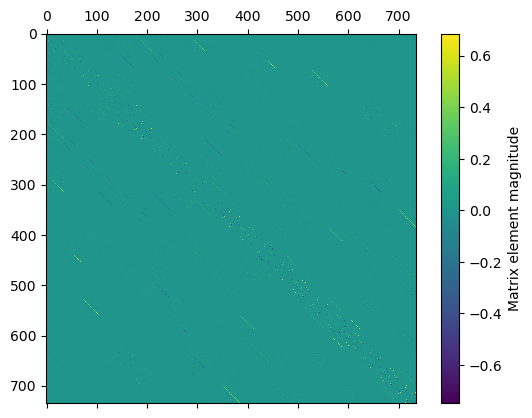

In [11]:
fig, ax = plt.subplots()
np.fill_diagonal(full_hamiltonian, 0.0)
im = ax.matshow(full_hamiltonian)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element magnitude')
plt.show()

In [ ]:
mysci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2, ecore=mf.mol.energy_nuc())

# Trying again

In [8]:
mol = gto.Mole()
mol.output = None
mol.atom = [
    ['H', ( 1.,-1.    , 0.   )],
    ['H', ( 0.,-1.    ,-1.   )],
    ['H', ( 1.,-0.5   ,-1.   )],
    ['H', ( 0.,-0.    ,-1.   )],
    ['H', ( 1.,-0.5   , 0.   )],
    ['H', ( 0., 1.    , 1.   )],
    ['H', ( 1., 2.    , 3.   )],
    ['H', ( 1., 2.    , 4.   )],
]
mol.basis = 'sto-3g'
mol.build()

m = scf.RHF(mol)
m.kernel()
norb = m.mo_coeff.shape[1]
nelec = mol.nelectron
h1e = reduce(np.dot, (m.mo_coeff.T, m.get_hcore(), m.mo_coeff))
eri = ao2mo.kernel(m._eri, m.mo_coeff, compact=False)
eri = eri.reshape(norb,norb,norb,norb)

e1, c1 = mysci.kernel(h1e, eri, norb, nelec, verbose=2)
e2, c2 = fci.direct_spin1.kernel(h1e, eri, norb, nelec)
print(e1, c1)
print(e2, c2)
print(e1, e1 - -11.894559902235565, 'diff to FCI', e1-e2)

converged SCF energy = -3.65698303621991
-11.894703079187677 [[ 4.22334961e-01 -5.05281870e-01  9.20085981e-03 ... -2.64218468e-05
   4.59413403e-05 -8.58829845e-05]
 [-5.05281870e-01 -2.87896091e-01  4.45643746e-03 ... -1.07578562e-04
  -9.97113627e-05 -5.31168279e-05]
 [ 9.20085981e-03  4.45643746e-03 -2.71271813e-04 ... -1.57953411e-05
   4.83610138e-05  3.81164129e-05]
 ...
 [-2.64218468e-05 -1.07578562e-04 -1.57953411e-05 ... -1.84277160e-04
   2.56879989e-04  2.40327169e-04]
 [ 4.59413403e-05 -9.97113627e-05  4.83610138e-05 ...  2.56879989e-04
  -6.37494191e-04  8.31313449e-04]
 [-8.58829845e-05 -5.31168279e-05  3.81164129e-05 ...  2.40327169e-04
   8.31313449e-04  6.35750855e-04]]
-11.894725066101488 [[ 4.22329276e-01 -5.05266885e-01  9.20693298e-03 ...  5.33071890e-05
   4.70322124e-05 -8.35154191e-05]
 [-5.05266885e-01 -2.87886733e-01  4.45743887e-03 ... -1.83847397e-04
  -1.02258723e-04 -5.61559415e-05]
 [ 9.20693298e-03  4.45743887e-03 -2.71741788e-04 ...  1.14900790e-05
   

In [10]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = np.stack([m.mo_coeff, m.mo_coeff])
norb = mo.shape[1]
hcore = m.get_hcore()
eri_ao = m._eri
add_thresh = 0.01

myhci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2, ecore=mf.mol.energy_nuc())

[[ 0  0]
 [ 0 40]
 [ 0 44]
 [ 0 50]
 [ 1  1]
 [ 1  3]
 [ 1  4]
 [ 1  5]
 [ 1 15]
 [ 1 35]
 [ 3  1]
 [ 3  3]
 [ 3  4]
 [ 3  7]
 [ 3  8]
 [ 3 35]
 [ 3 38]
 [ 4  1]
 [ 4  3]
 [ 4  4]
 [ 4  5]
 [ 4  7]
 [ 4 37]
 [ 4 38]
 [ 5  1]
 [ 5  4]
 [ 5  5]
 [ 5  7]
 [ 5 15]
 [ 5 35]
 [ 6 16]
 [ 7  3]
 [ 7  4]
 [ 7  5]
 [ 7  7]
 [ 7  8]
 [ 7 35]
 [ 7 37]
 [ 7 38]
 [ 8  3]
 [ 8  7]
 [ 8  8]
 [ 8 37]
 [ 8 38]
 [15  1]
 [15  5]
 [15 16]
 [16  6]
 [16 15]
 [16 16]
 [35  1]
 [35  3]
 [35  5]
 [35  7]
 [35 35]
 [37  4]
 [37  7]
 [37  8]
 [37 37]
 [37 38]
 [38  3]
 [38  4]
 [38  7]
 [38  8]
 [38 37]
 [38 38]
 [40  0]
 [44  0]
 [50  0]]
[array([ 0.75362217,  0.0705958 ,  0.10066167,  0.10306964, -0.02773982,
       -0.06188608,  0.03415516, -0.08277847, -0.02136206,  0.07291519,
       -0.06188608,  0.0498856 ,  0.07808551,  0.0454636 ,  0.07765663,
        0.0628234 ,  0.10027097,  0.03415516,  0.07808551,  0.09682517,
        0.0401266 ,  0.0823099 ,  0.10021355,  0.10740469, -0.08277847,
        0.0401266

KeyboardInterrupt: 